In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")

TRAIN_DIR = 'train'
TEST_DIR = 'test'
IMAGE_SIZE = 48
BATCH_SIZE = 32
NUM_CLASSES = 7
CHANNELS = 1

Kullanılan cihaz: cuda


In [19]:
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), 
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), 
    transforms.ToTensor(), 
])

test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

try:
    train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
    test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=test_transforms)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    print(f"Eğitim sınıf sayısı: {len(train_dataset.classes)}")
    print(f"Test sınıf sayısı: {len(test_dataset.classes)}")
except FileNotFoundError:
    print("HATA: 'train' veya 'test' klasörleri bulunamadı. Lütfen veri seti yolunu kontrol edin.")

Eğitim sınıf sayısı: 7
Test sınıf sayısı: 7


In [20]:
class FacialExpressionModel(nn.Module):
    def __init__(self, num_classes=7):
        super(FacialExpressionModel, self).__init__()
        self.gray_to_rgb = nn.Sequential(
            nn.Conv2d(1, 3, kernel_size=3, padding=1),
            nn.ReLU()
        )
        
        self.base_model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        
        for param in self.base_model.parameters():
            param.requires_grad = False
            
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1280, 512), 
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.gray_to_rgb(x)
        x = self.base_model.features(x)
        x = self.classifier(x)
        return x

model = FacialExpressionModel(NUM_CLASSES).to(device)

print(model)

FacialExpressionModel(
  (gray_to_rgb): Sequential(
    (0): Conv2d(1, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (base_model): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
     

In [21]:
history = {
    'accuracy': [], 'val_accuracy': [],
    'loss': [], 'val_loss': []
}

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, start_epoch=0, scheduler=None):
    
    for epoch in range(start_epoch, start_epoch + num_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        
        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)
        
        model.eval()
        val_running_loss = 0.0
        val_running_corrects = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                _, preds = torch.max(outputs, 1)
                val_running_loss += loss.item() * inputs.size(0)
                val_running_corrects += torch.sum(preds == labels.data)
        
        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = val_running_corrects.double() / len(val_loader.dataset)
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc.item())
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc.item())
        
        print(f'Epoch {epoch+1}/{start_epoch + num_epochs} - '
              f'Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} - '
              f'Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f}')
        
        if scheduler:
            scheduler.step()
            
    return model

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

EPOCHS_PHASE_1 = 30

print("Aşama 1: Base Model Donuk Eğitim Başlıyor...")
model = train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=EPOCHS_PHASE_1)

Aşama 1: Base Model Donuk Eğitim Başlıyor...
Epoch 1/30 - Loss: 1.7698 Acc: 0.2805 - Val Loss: 1.7085 Val Acc: 0.3121
Epoch 2/30 - Loss: 1.7411 Acc: 0.2912 - Val Loss: 1.6990 Val Acc: 0.3026
Epoch 3/30 - Loss: 1.7353 Acc: 0.2957 - Val Loss: 1.6720 Val Acc: 0.3274
Epoch 4/30 - Loss: 1.7324 Acc: 0.2969 - Val Loss: 1.6850 Val Acc: 0.3196
Epoch 5/30 - Loss: 1.7318 Acc: 0.3002 - Val Loss: 1.6802 Val Acc: 0.3186
Epoch 6/30 - Loss: 1.7288 Acc: 0.2970 - Val Loss: 1.6776 Val Acc: 0.3203
Epoch 7/30 - Loss: 1.7228 Acc: 0.3038 - Val Loss: 1.6829 Val Acc: 0.3167
Epoch 8/30 - Loss: 1.7298 Acc: 0.2947 - Val Loss: 1.6790 Val Acc: 0.3327
Epoch 9/30 - Loss: 1.7211 Acc: 0.3026 - Val Loss: 1.6648 Val Acc: 0.3402
Epoch 10/30 - Loss: 1.7205 Acc: 0.3037 - Val Loss: 1.6800 Val Acc: 0.3176
Epoch 11/30 - Loss: 1.7186 Acc: 0.3022 - Val Loss: 1.6758 Val Acc: 0.3328
Epoch 12/30 - Loss: 1.7187 Acc: 0.3056 - Val Loss: 1.6849 Val Acc: 0.3096
Epoch 13/30 - Loss: 1.7245 Acc: 0.3027 - Val Loss: 1.6833 Val Acc: 0.3144
Ep

In [27]:
for param in model.base_model.parameters():
    param.requires_grad = True

fine_tune_at = 12 
for i, child in enumerate(model.base_model.features.children()):
    if i < fine_tune_at:
        for param in child.parameters():
            param.requires_grad = False

optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)

EPOCHS_PHASE_2 = 10

print("\nAşama 2: Fine-Tuning Başlıyor...")
model = train_model(
    model, train_loader, test_loader, criterion, optimizer_ft, 
    num_epochs=EPOCHS_PHASE_2, 
    start_epoch=EPOCHS_PHASE_1
)


Aşama 2: Fine-Tuning Başlıyor...
Epoch 31/40 - Loss: 1.5898 Acc: 0.3764 - Val Loss: 1.5112 Val Acc: 0.4108
Epoch 32/40 - Loss: 1.5802 Acc: 0.3835 - Val Loss: 1.5123 Val Acc: 0.4065
Epoch 33/40 - Loss: 1.5680 Acc: 0.3893 - Val Loss: 1.4833 Val Acc: 0.4199
Epoch 34/40 - Loss: 1.5573 Acc: 0.3924 - Val Loss: 1.4828 Val Acc: 0.4189
Epoch 35/40 - Loss: 1.5520 Acc: 0.3955 - Val Loss: 1.4682 Val Acc: 0.4292
Epoch 36/40 - Loss: 1.5402 Acc: 0.4024 - Val Loss: 1.4497 Val Acc: 0.4405
Epoch 37/40 - Loss: 1.5275 Acc: 0.4074 - Val Loss: 1.4442 Val Acc: 0.4352
Epoch 38/40 - Loss: 1.5302 Acc: 0.4030 - Val Loss: 1.4425 Val Acc: 0.4372
Epoch 39/40 - Loss: 1.5226 Acc: 0.4085 - Val Loss: 1.4472 Val Acc: 0.4347
Epoch 40/40 - Loss: 1.5169 Acc: 0.4109 - Val Loss: 1.4352 Val Acc: 0.4366


In [29]:
optimizer_final = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

def lr_lambda(epoch):
    if epoch < 10:
        return 1.0
    else:
        return 0.6065 ** (epoch - 10) 
scheduler = optim.lr_scheduler.LambdaLR(optimizer_final, lr_lambda=lr_lambda)

EPOCHS_PHASE_3 = 10
START_EPOCH_3 = EPOCHS_PHASE_1 + EPOCHS_PHASE_2

print("\nAşama 3: Scheduler ile Son Eğitim...")
model = train_model(
    model, train_loader, test_loader, criterion, optimizer_final, 
    num_epochs=EPOCHS_PHASE_3, 
    start_epoch=START_EPOCH_3,
    scheduler=scheduler
)


Aşama 3: Scheduler ile Son Eğitim...
Epoch 41/50 - Loss: 1.5434 Acc: 0.4014 - Val Loss: 1.4520 Val Acc: 0.4419
Epoch 42/50 - Loss: 1.5012 Acc: 0.4204 - Val Loss: 1.3992 Val Acc: 0.4578
Epoch 43/50 - Loss: 1.4768 Acc: 0.4330 - Val Loss: 1.3852 Val Acc: 0.4549
Epoch 44/50 - Loss: 1.4549 Acc: 0.4434 - Val Loss: 1.3691 Val Acc: 0.4784
Epoch 45/50 - Loss: 1.4392 Acc: 0.4514 - Val Loss: 1.3428 Val Acc: 0.4837
Epoch 46/50 - Loss: 1.4198 Acc: 0.4607 - Val Loss: 1.3307 Val Acc: 0.4872
Epoch 47/50 - Loss: 1.4108 Acc: 0.4650 - Val Loss: 1.3116 Val Acc: 0.4990
Epoch 48/50 - Loss: 1.3993 Acc: 0.4700 - Val Loss: 1.2984 Val Acc: 0.5024
Epoch 49/50 - Loss: 1.3844 Acc: 0.4758 - Val Loss: 1.3122 Val Acc: 0.4953
Epoch 50/50 - Loss: 1.3719 Acc: 0.4825 - Val Loss: 1.2984 Val Acc: 0.5047


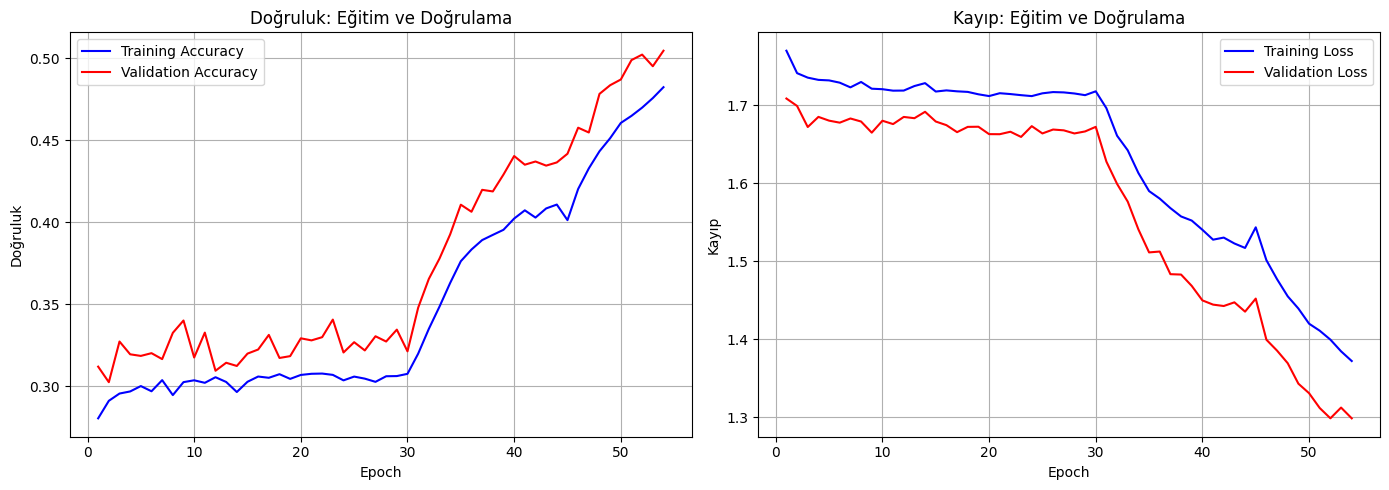

In [30]:
acc = history['accuracy']
val_acc = history['val_accuracy']
loss = history['loss']
val_loss = history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'b', label='Training Accuracy')
plt.plot(epochs_range, val_acc, 'r', label='Validation Accuracy')
plt.title('Doğruluk: Eğitim ve Doğrulama')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'b', label='Training Loss')
plt.plot(epochs_range, val_loss, 'r', label='Validation Loss')
plt.title('Kayıp: Eğitim ve Doğrulama')
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Tahminler alınıyor...
Tahminler başarıyla alındı.


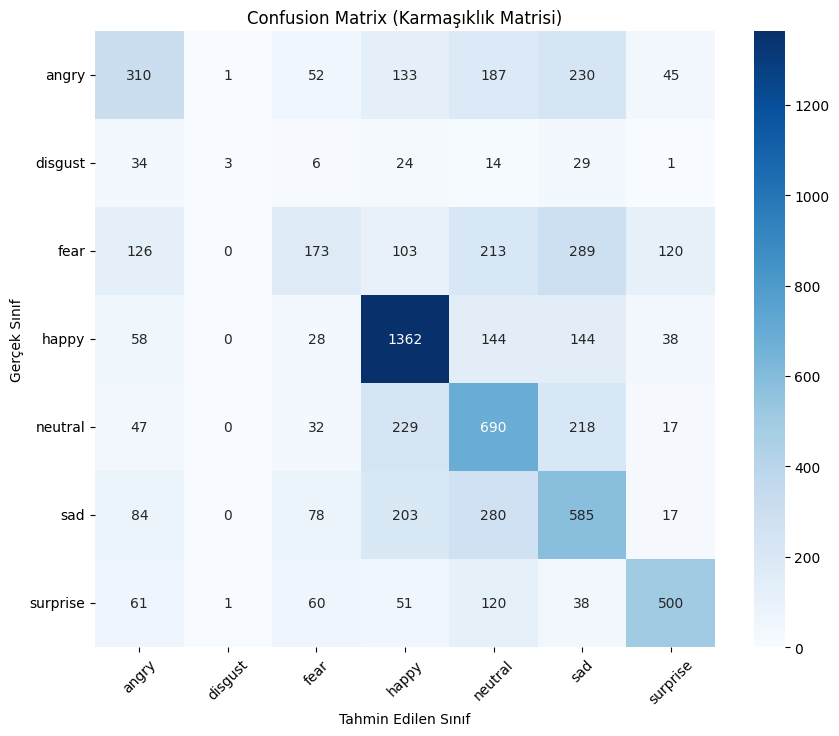


Sınıflandırma Raporu:

              precision    recall  f1-score   support

       angry       0.43      0.32      0.37       958
     disgust       0.60      0.03      0.05       111
        fear       0.40      0.17      0.24      1024
       happy       0.65      0.77      0.70      1774
     neutral       0.42      0.56      0.48      1233
         sad       0.38      0.47      0.42      1247
    surprise       0.68      0.60      0.64       831

    accuracy                           0.50      7178
   macro avg       0.51      0.42      0.41      7178
weighted avg       0.50      0.50      0.49      7178



In [31]:
print("Tahminler alınıyor...")
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("Tahminler başarıyla alındı.")

class_names = train_dataset.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True,              
    fmt='d',                 
    cmap='Blues',           
    xticklabels=class_names,
    yticklabels=class_names, 
    cbar=True               
)

plt.title('Confusion Matrix (Karmaşıklık Matrisi)')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.yticks(rotation=0)
plt.xticks(rotation=45)
plt.show()

print("\nSınıflandırma Raporu:\n")
print(classification_report(y_true, y_pred, target_names=class_names))